# Computer Vision - Assignment 2

In [ ]:
!pip install https://github.com/openai/CLIP/archive/main.zip

In [ ]:
!pip install transformers

In [ ]:
!pip install huggingface_hub

In [ ]:
import torch
import os
import clip 
from datasets import load_dataset, concatenate_datasets
from transformers import AutoImageProcessor, AutoModel
from tqdm.auto import tqdm
from huggingface_hub import login

#Hugging face token- login not needed
HF_TOKEN = "TOKEN_REMOVED_FOR_SUBMISSION" 

# login to Hugging face
try:
    login(token=HF_TOKEN)
    print("logged in")
except Exception as e:
    print(f"no login {e}")

#use CUDA if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Create directory for saving features
os.makedirs("saved_features", exist_ok=True)

# Define models
models_config = {
    "DINOv2": "facebook/dinov2-small",
    "CLIP": "RN50",
    "ConvNeXt": "facebook/convnext-tiny-224"
}

# define datasets
datasets_config = {
    "EuroSAT": "tanganke/eurosat", 
    "StanfordCars": "tanganke/stanford_cars" 
}

def load_backbone(model_name, identifier):
    """Loads the model and its processor"""
    if model_name == "CLIP":
        model, processor = clip.load(identifier, device=device)
        model.eval()
        return processor, model
    else:
        processor = AutoImageProcessor.from_pretrained(identifier)
        model = AutoModel.from_pretrained(identifier).to(device)
        model.eval()
        return processor, model

def load_and_combine_dataset(dataset_name, hf_path):
    """Loads and combines train and test splits"""
    print(f"Loading {dataset_name}...")
    dataset = load_dataset(hf_path, trust_remote_code=True)
        
    splits = []
    if 'train' in dataset: splits.append(dataset['train'])
    if 'test' in dataset: splits.append(dataset['test'])
    
    return concatenate_datasets(splits)

@torch.no_grad()
def extract_and_save_features():
    """Extracts features from all images and saves them to disk"""
    for ds_name, ds_path in datasets_config.items():
        dataset = load_and_combine_dataset(ds_name, ds_path)
        
        # filter to keep RGB images only
        dataset = dataset.filter(lambda example: example['image'].mode == 'RGB')
        labels = torch.tensor(dataset['label'])
        
        for model_name, model_identifier in models_config.items():
            print(f"\nExtracting features for {ds_name} using {model_name}...")
            processor, model = load_backbone(model_name, model_identifier)
            
            features = []
            batch_size = 64
            
            for i in tqdm(range(0, len(dataset), batch_size)):
                batch_images = dataset[i : i + batch_size]['image']
                
                if model_name == "CLIP":
                    inputs = torch.stack([processor(img) for img in batch_images]).to(device)
                    batch_features = model.encode_image(inputs)
                    batch_features = batch_features / batch_features.norm(dim=-1, keepdim=True)
                else:
                    inputs = processor(images=batch_images, return_tensors="pt").to(device)
                    outputs = model(**inputs)
                    batch_features = outputs.pooler_output if hasattr(outputs, 'pooler_output') and outputs.pooler_output is not None else outputs.last_hidden_state[:, 0, :]
                
                features.append(batch_features.cpu())
            
            # concatenate and convert to float32 to prevent dtype mismatch
            all_features = torch.cat(features, dim=0).float()
            
            save_path = f"saved_features/{ds_name}_{model_name}.pt"
            torch.save({'features': all_features, 'labels': labels}, save_path)
            print(f"Saved -> {save_path} (Shape: {all_features.shape})")

if __name__ == "__main__":
    extract_and_save_features()
    print("\ncompleted!")

logged in
Loading EuroSAT...

Extracting features for EuroSAT using DINOv2...


100%|██████████| 380/380 [44:46<00:00,  7.07s/it] 


Saved -> saved_features/EuroSAT_DINOv2.pt (Shape: torch.Size([24300, 384]))

Extracting features for EuroSAT using CLIP...


100%|██████████| 380/380 [49:26<00:00,  7.81s/it]


Saved -> saved_features/EuroSAT_CLIP.pt (Shape: torch.Size([24300, 1024]))

Extracting features for EuroSAT using ConvNeXt...


...

Saved -> saved_features/StanfordCars_DINOv2.pt (Shape: torch.Size([16151, 384]))

Extracting features for StanfordCars using CLIP...


100%|██████████| 253/253 [35:33<00:00,  8.43s/it]


Saved -> saved_features/StanfordCars_CLIP.pt (Shape: torch.Size([16151, 1024]))

Extracting features for StanfordCars using ConvNeXt...


Loading weights: 100%|██████████| 180/180 [00:00<00:00, 13020.40it/s]
[transformers] ConvNextModel LOAD REPORT from: facebook/convnext-tiny-224
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
100%|██████████| 253/253 [26:11<00:00,  6.21s/it]


Saved -> saved_features/StanfordCars_ConvNeXt.pt (Shape: torch.Size([16151, 768]))

completed!


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim

# few shot task sampler
def sample_few_shot(features, labels, k_shots, num_queries=15):
    """
    samples k support and 15 query examples per class
    """
    unique_classes = torch.unique(labels)
    num_classes = len(unique_classes)

    X_S, Y_S, X_Q, Y_Q = [], [], [], []

    for c in unique_classes:
        # get all indices for class c
        idx = (labels == c).nonzero(as_tuple=True)[0]

        # shuffle indices
        idx = idx[torch.randperm(len(idx))]

        # split into support and query
        X_S.append(features[idx[:k_shots]])
        Y_S.append(labels[idx[:k_shots]])

        X_Q.append(features[idx[k_shots:k_shots + num_queries]])
        Y_Q.append(labels[idx[k_shots:k_shots + num_queries]])

    # concatenate lists into single tensors
    X_S = torch.cat(X_S, dim=0)
    Y_S = torch.cat(Y_S, dim=0)
    X_Q = torch.cat(X_Q, dim=0)
    Y_Q = torch.cat(Y_Q, dim=0)

    return X_S, Y_S, X_Q, Y_Q, num_classes

# classification heads

#Prototypical classifier
def prototypical_classifier(X_S, Y_S, X_Q, num_classes):
    """
    classifies queries based on euclidean distance to class means
    """
    prototypes = []

    # calculate mean vector, prototype, for each class
    for c in range(num_classes):
        prototypes.append(X_S[Y_S == c].mean(dim=0))

    prototypes = torch.stack(prototypes)

    # compute distances and find nearest prototype
    distances = torch.cdist(X_Q, prototypes)
    predictions = torch.argmin(distances, dim=1)

    return predictions

#Ridge regression classifier
def ridge_regression_classifier(X_S, Y_S, X_Q, num_classes, lambda_reg=0.1):
    """
    solve linear regression using the formula:
    W = (X^T X + lambda I)^(-1) X^T Y
    """
    N, D = X_S.shape

    # convert labels to one hot encoding
    Y_onehot = torch.zeros(N, num_classes, device=X_S.device)
    Y_onehot.scatter_(1, Y_S.unsqueeze(1), 1.0)

    # calculate weights using torch.linalg.solve
    I = torch.eye(D, device=X_S.device)
    A = torch.matmul(X_S.t(), X_S) + lambda_reg * I
    B = torch.matmul(X_S.t(), Y_onehot)
    W = torch.linalg.solve(A, B)

    # predict query labels
    logits = torch.matmul(X_Q, W)
    predictions = torch.argmax(logits, dim=1)

    return predictions

#Linear probing
def linear_probing_classifier(X_S, Y_S, X_Q, num_classes, epochs=40, lr=0.01):
    """
    trains a single linear layer using gradient descent on the support set
    """
    D = X_S.shape[1]

    # initialize linear layer and optimizer
    model = nn.Linear(D, num_classes).to(X_S.device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # train on support set
    model.train()
    for _ in range(epochs):
        optimizer.zero_grad()
        loss = criterion(model(X_S), Y_S)
        loss.backward()
        optimizer.step()

    # evaluate on the query set
    model.eval()
    with torch.no_grad():
        logits = model(X_Q)
        predictions = torch.argmax(logits, dim=1)

    return predictions

In [ ]:
import torch
import pandas as pd
import numpy as np
import random
import os
from tqdm.auto import tqdm

def set_seed(seed=42):
    """
    forces all random processes to use the same seed (42)
    tried, torch.manual_seed(42) only, yet the tasks between
    prototypical and ridge were different at same stage
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

# apply seed 42
set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Running benchmark on: {device}")

# configuration
datasets = ["EuroSAT", "StanfordCars"]
backbones = ["DINOv2", "CLIP", "ConvNeXt"]
k_shots_list = [1, 2, 4, 16]
num_episodes = 10000 

csv_filename = "few_shot_benchmark.csv"

completed_configs = set()
benchmark_results = []

# run resume
if os.path.exists(csv_filename):
    print(f"found CSV- resume")
    df_existing = pd.read_csv(csv_filename)
    benchmark_results = df_existing.to_dict('records')
    for _, row in df_existing.iterrows():
        completed_configs.add((row['Dataset'], row['Backbone'], row['Shots (K)']))

# benchmark loop
for ds in datasets:
    for backbone in backbones:

        feature_path = f"saved_features/{ds}_{backbone}.pt"
        if not os.path.exists(feature_path):
            print(f"no file- {feature_path} - skip")
            continue

        # load features and labels
        data = torch.load(feature_path)

        # move all data to GPU
        features = data['features'].to(device).float()
        labels = data['labels'].to(device)

        for k in k_shots_list:
            # skip if was already computed
            if (ds, backbone, k) in completed_configs:
                print(f"skip {ds} | {backbone} | {k}-shot already completed")
                continue

            # store accuracy for every single episode to calculate std
            acc_proto_list = np.zeros(num_episodes)
            acc_ridge_list = np.zeros(num_episodes)
            acc_linear_list = np.zeros(num_episodes)

            # progress bar
            desc = f"{ds[:8]:<8} | {backbone:<8} | {k:>2}-shot"
            for episode in tqdm(range(num_episodes), desc=desc, leave=False):

                # sample a random episode on the GPU
                X_S, Y_S, X_Q, Y_Q, num_classes = sample_few_shot(features, labels, k_shots=k)

                # Prototypical network
                pred_proto = prototypical_classifier(X_S, Y_S, X_Q, num_classes)
                acc_proto_list[episode] = (pred_proto == Y_Q).float().mean().item() * 100

                # Ridge regression
                pred_ridge = ridge_regression_classifier(X_S, Y_S, X_Q, num_classes, lambda_reg=0.1)
                acc_ridge_list[episode] = (pred_ridge == Y_Q).float().mean().item() * 100

                # Linear probing
                pred_linear = linear_probing_classifier(X_S, Y_S, X_Q, num_classes, epochs=20, lr=0.01)
                acc_linear_list[episode] = (pred_linear == Y_Q).float().mean().item() * 100

            #calculate Mean and Standard Deviation (Std)
            mean_proto = acc_proto_list.mean()
            std_proto = acc_proto_list.std()
            
            mean_ridge = acc_ridge_list.mean()
            std_ridge = acc_ridge_list.std()
            
            mean_linear = acc_linear_list.mean()
            std_linear = acc_linear_list.std()

            # append to results
            benchmark_results.append({
                "Dataset": ds,
                "Backbone": backbone,
                "Shots (K)": k,
                "Prototypical Mean (%)": mean_proto,
                "Prototypical Std (%)": std_proto,
                "Ridge Mean (%)": mean_ridge,
                "Ridge Std (%)": std_ridge,
                "Linear Mean (%)": mean_linear,
                "Linear Std (%)": std_linear
            })

            # save to CSV after each configuration completes
            pd.DataFrame(benchmark_results).to_csv(csv_filename, index=False)

            # print current combination results with std
            print(f"{desc} -> Prototypical: {mean_proto:.2f}&{std_proto:.2f}% | Ridge: {mean_ridge:.2f}&{std_ridge:.2f}% | Linear: {mean_linear:.2f}&{std_linear:.2f}%")

print("\n completed!")
df_results = pd.DataFrame(benchmark_results)
print(df_results.to_string(index=False))

Running benchmark on: cpu


EuroSAT  | DINOv2   |  1-shot -> Prototypical: 51.00&6.27% | Ridge: 52.40&6.31% | Linear: 44.41&6.39%


EuroSAT  | DINOv2   |  2-shot -> Prototypical: 61.92&5.13% | Ridge: 64.29&5.23% | Linear: 55.33&5.95%


EuroSAT  | DINOv2   |  4-shot -> Prototypical: 69.67&4.34% | Ridge: 73.34&4.27% | Linear: 66.91&5.06%


EuroSAT  | DINOv2   | 16-shot -> Prototypical: 76.95&3.53% | Ridge: 79.38&3.45% | Linear: 83.13&3.28%


...

Stanford | CLIP     | 16-shot -> Prototypical: 60.14&0.90% | Ridge: 62.63&0.85% | Linear: 64.45&0.87%


Stanford | ConvNeXt |  1-shot -> Prototypical: 10.13&0.70% | Ridge: 9.15&0.65% | Linear: 10.14&0.69%


Stanford | ConvNeXt |  2-shot -> Prototypical: 14.38&0.76% | Ridge: 11.96&0.70% | Linear: 15.56&0.79%


Stanford | ConvNeXt |  4-shot -> Prototypical: 19.49&0.78% | Ridge: 15.37&0.72% | Linear: 22.87&0.84%


Stanford | ConvNeXt | 16-shot -> Prototypical: 28.46&0.76% | Ridge: 43.85&0.86% | Linear: 37.84&0.85%

 completed!
     Dataset Backbone  Shots (K)  Prototypical Mean (%)  Prototypical Std (%)  Ridge Mean (%)  Ridge Std (%)  Linear Mean (%)  Linear Std (%)
     EuroSAT   DINOv2          1              50.998067              6.272061       52.398067       6.314279        44.410467        6.388942
     EuroSAT   DINOv2          2              61.918333              5.129674       64.285933       5.230218        55.326667        5.948815
     EuroSAT   DINOv2          4              69.673000              4.338341       73.344600       4.272569        66.910000        5.061602
     EuroSAT   DINOv2         16              76.954933              3.529811       79.380067       3.452856        83.126667        3.277594
     EuroSAT     CLIP          1              47.053133              6.287252       49.606133       6.244726        51.034400        6.255839
     EuroSAT     CLIP          2 

In [ ]:
!pip install umap-learn

benchmark table
loaded few_shot_benchmark.csv 

     Dataset Backbone  Shots (K)  Prototypical Mean (%)  Prototypical Std (%)  Ridge Mean (%)  Ridge Std (%)  Linear Mean (%)  Linear Std (%)
     EuroSAT   DINOv2          1              50.998067              6.272061       52.398067       6.314279        44.410467        6.388942
     EuroSAT   DINOv2          2              61.918333              5.129674       64.285933       5.230218        55.326667        5.948815
     EuroSAT   DINOv2          4              69.673000              4.338341       73.344600       4.272569        66.910000        5.061602
     EuroSAT   DINOv2         16              76.954933              3.529811       79.380067       3.452856        83.126667        3.277594
     EuroSAT     CLIP          1              47.053133              6.287252       49.606133       6.244726        51.034400        6.255839
     EuroSAT     CLIP          2              57.296267              5.255368       61.398800       

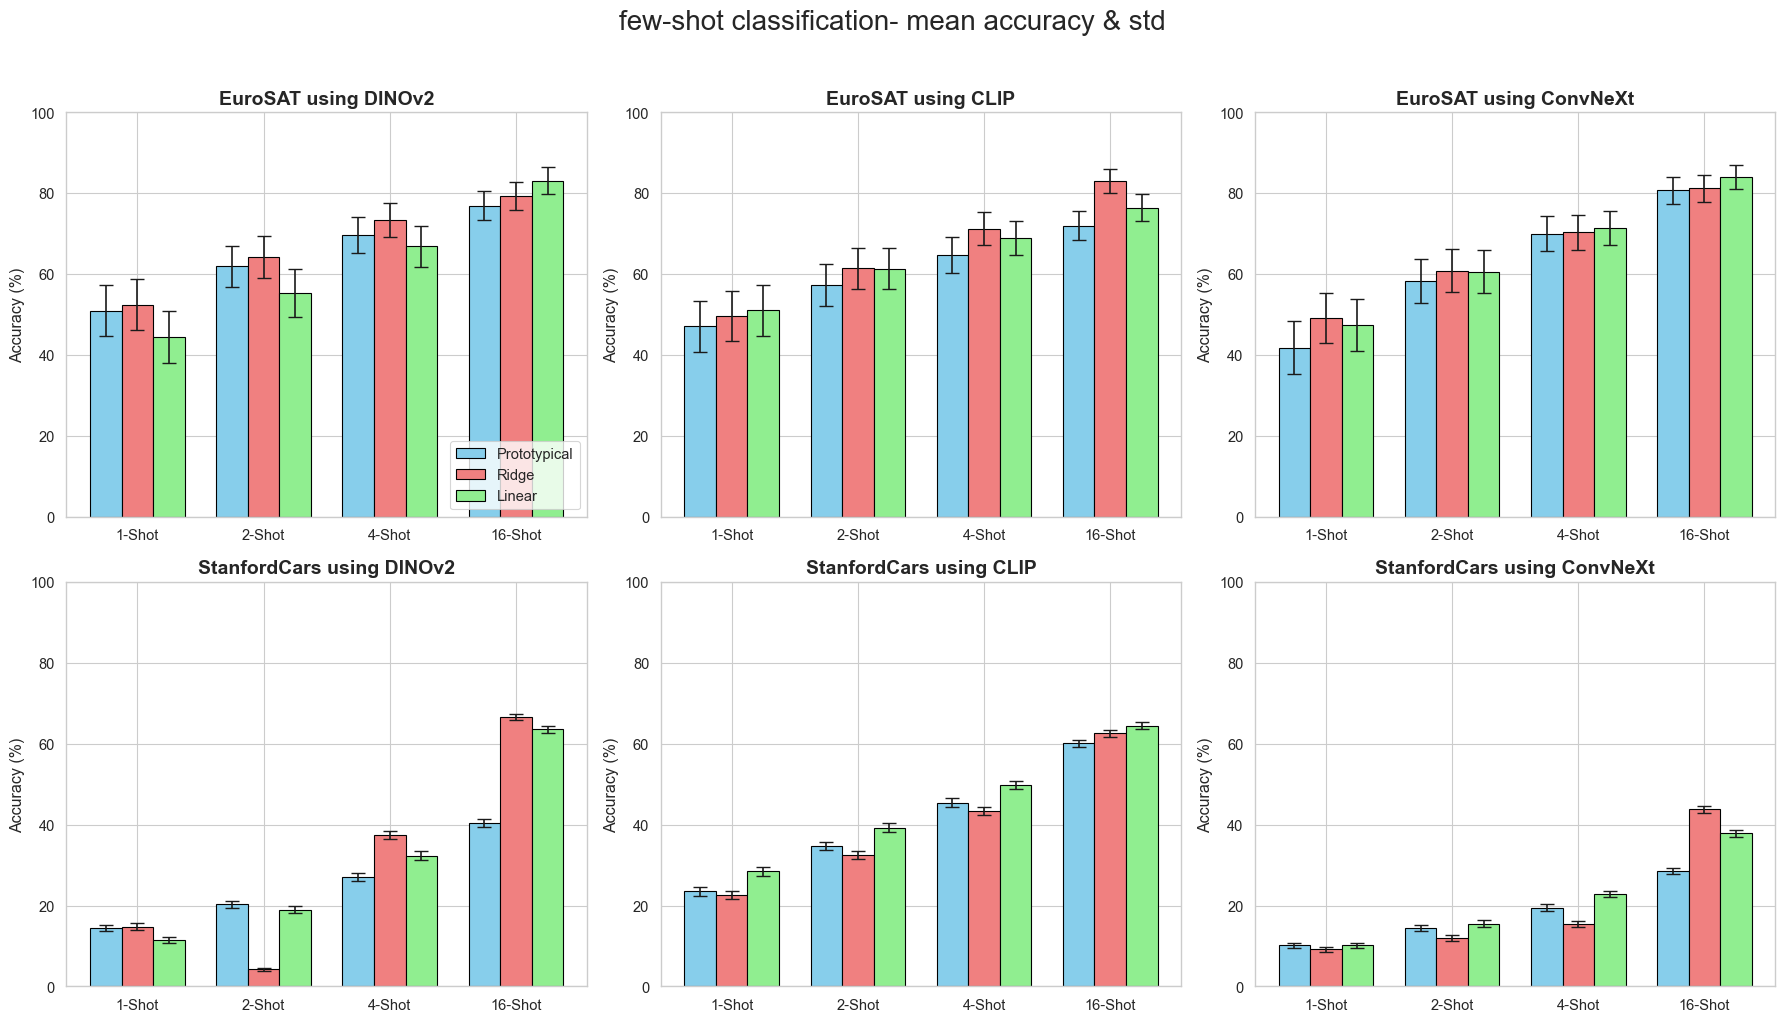

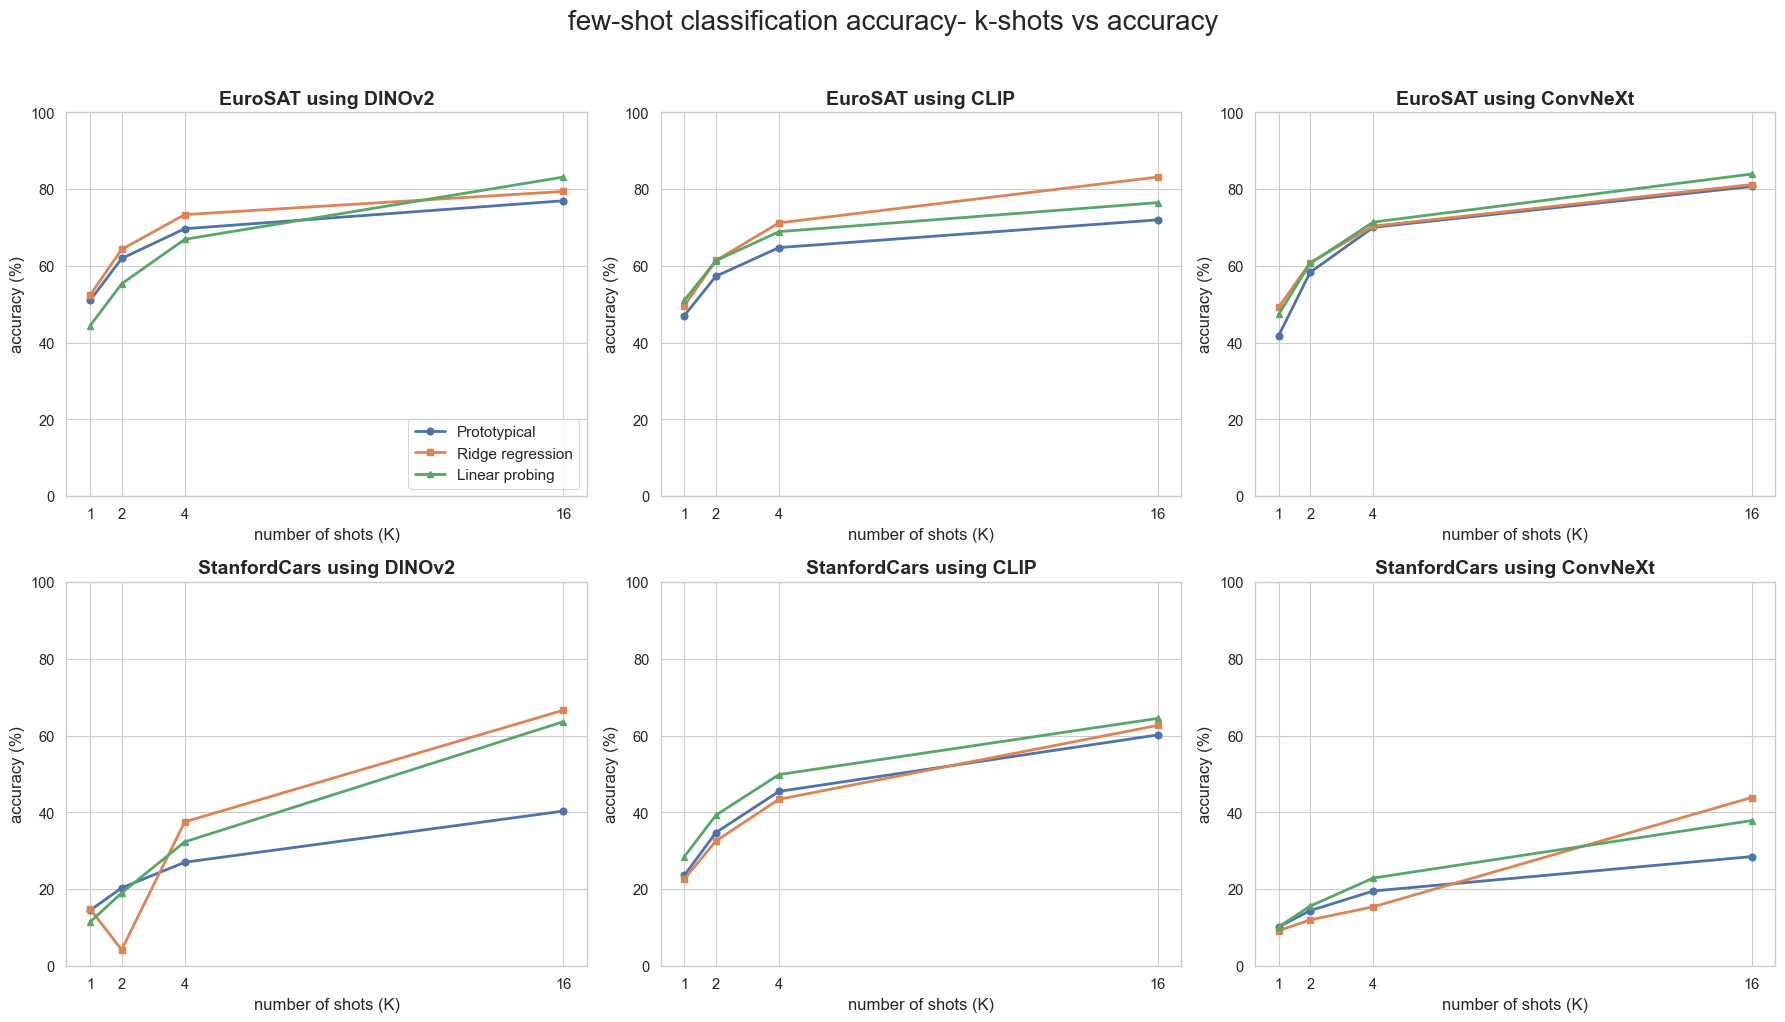


training dynamics- stanfordCars+clip


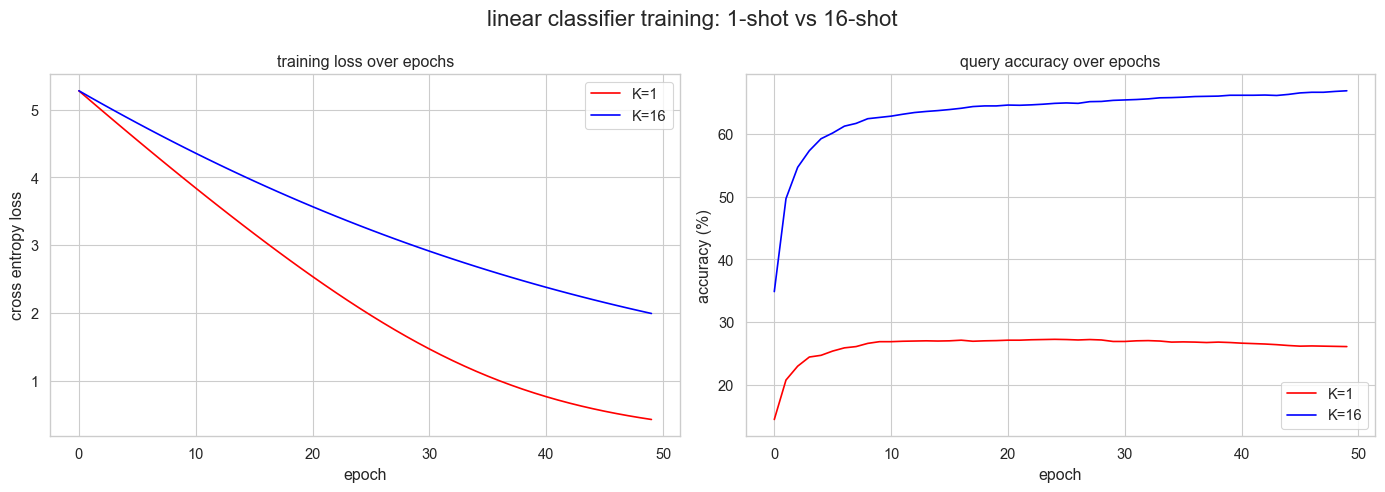

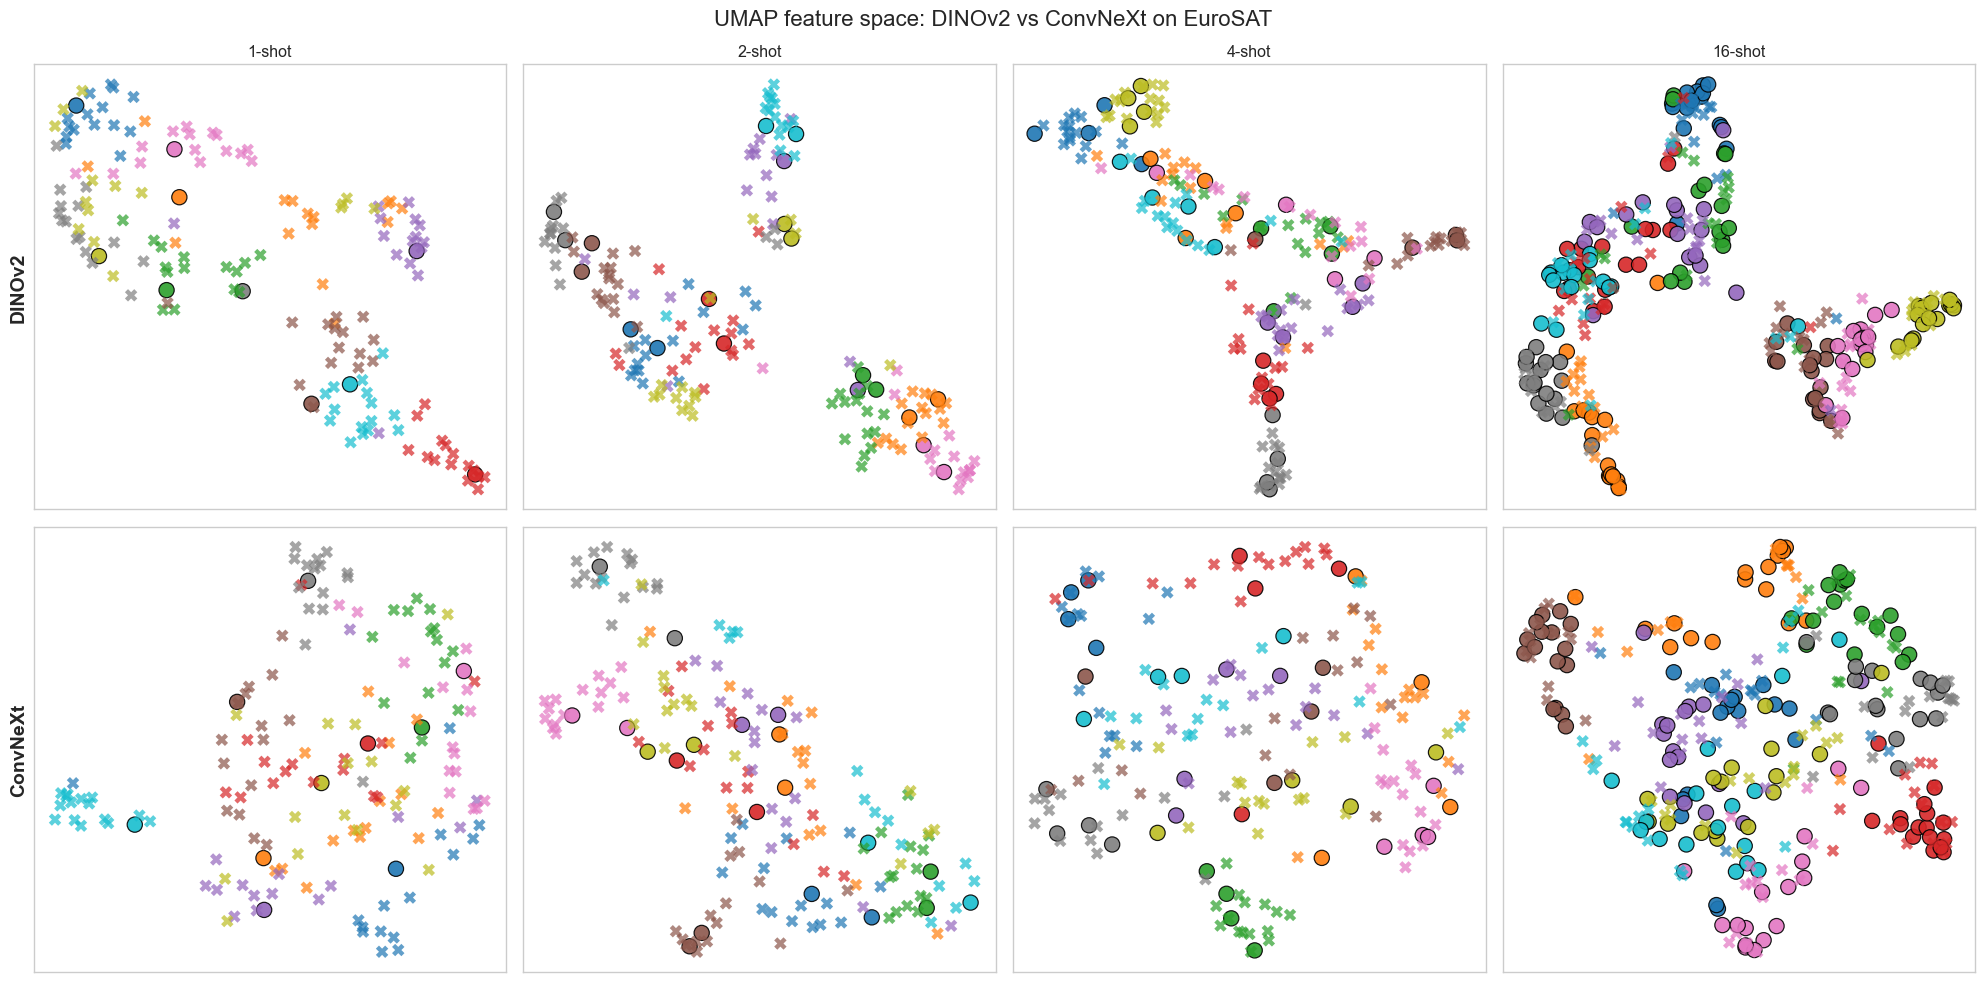

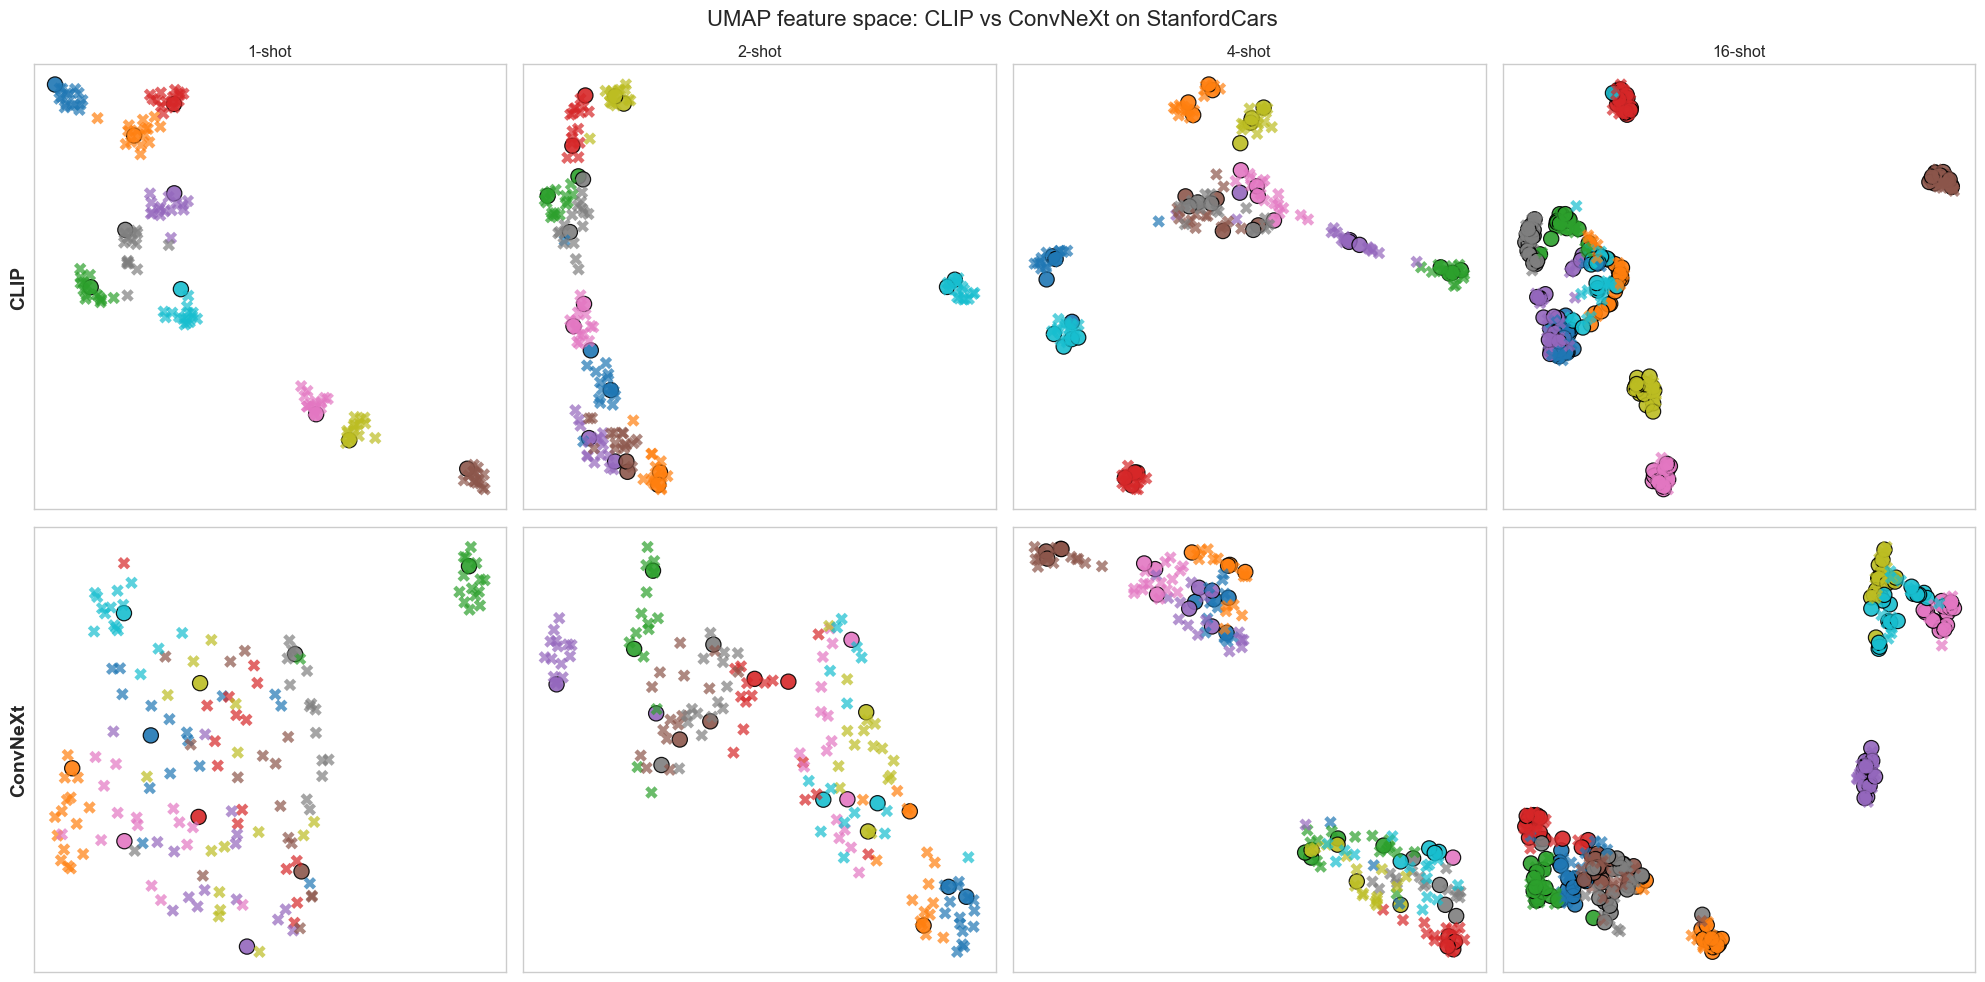

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import umap
import warnings

# benchmark results- table and chart
print("benchmark table")
csv_filename = "few_shot_benchmark.csv"

df = pd.read_csv(csv_filename)
print(f"loaded {csv_filename} \n")
print(df.to_string(index=False))


sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

datasets = df['Dataset'].unique()
backbones = df['Backbone'].unique()
k_shots_list = [1, 2, 4, 16]

# plotting bar charts with std
fig_bar, axes_bar = plt.subplots(nrows=len(datasets), ncols=len(backbones), figsize=(18, 10))
fig_bar.suptitle('few-shot classification- mean accuracy & std', fontsize=20, y=1.02)

for i, ds in enumerate(datasets):
    for j, bb in enumerate(backbones):
        ax = axes_bar[i, j]
        subset = df[(df['Dataset'] == ds) & (df['Backbone'] == bb)]
        
        x = np.arange(len(k_shots_list))
        width = 0.25
        
        # plotting bars with yerr for std
        ax.bar(x - width, subset['Prototypical Mean (%)'], width, yerr=subset['Prototypical Std (%)'], capsize=5, label='Prototypical', color='skyblue', edgecolor='black')
        ax.bar(x, subset['Ridge Mean (%)'], width, yerr=subset['Ridge Std (%)'], capsize=5, label='Ridge', color='lightcoral', edgecolor='black')
        ax.bar(x + width, subset['Linear Mean (%)'], width, yerr=subset['Linear Std (%)'], capsize=5, label='Linear', color='lightgreen', edgecolor='black')
        
        ax.set_title(f"{ds} using {bb}", fontsize=14, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels([f"{k}-Shot" for k in k_shots_list])
        ax.set_ylabel("Accuracy (%)")
        ax.set_ylim(0, 100)
        
        if i == 0 and j == 0:
            ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig("benchmark_charts.png", dpi=300, bbox_inches='tight')
plt.show()

#line plots

fig_line, axes_line = plt.subplots(nrows=len(datasets), ncols=len(backbones), figsize=(18, 10))
fig_line.suptitle('few-shot classification accuracy- k-shots vs accuracy', fontsize=20, y=1.02)

for i, ds in enumerate(datasets):
    for j, bb in enumerate(backbones):
        ax = axes_line[i, j]
        subset = df[(df['Dataset'] == ds) & (df['Backbone'] == bb)]
        
        ax.plot(subset['Shots (K)'], subset['Prototypical Mean (%)'], marker='o', linewidth=2, label='Prototypical')
        ax.plot(subset['Shots (K)'], subset['Ridge Mean (%)'], marker='s', linewidth=2, label='Ridge regression')
        ax.plot(subset['Shots (K)'], subset['Linear Mean (%)'], marker='^', linewidth=2, label='Linear probing')
        
        ax.set_title(f"{ds} using {bb}", fontsize=14, fontweight='bold')
        ax.set_xlabel("number of shots (K)", fontsize=12)
        ax.set_ylabel("accuracy (%)", fontsize=12)
        ax.set_xticks(k_shots_list)
        ax.set_ylim(0, 100) 
        
        if i == 0 and j == 0:
            ax.legend(loc='lower right', fontsize=11)

plt.tight_layout()
plt.savefig("few_shot_plots.png", dpi=300, bbox_inches='tight')
plt.show()

# training dynamics of linear classifier
device = torch.device('cpu')

def train_mlp_and_track(X_S, Y_S, X_Q, Y_Q, num_classes, epochs=50):
    model = nn.Linear(X_S.shape[1], num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    
    history = {'loss': [], 'acc': []}
    for _ in range(epochs):
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(X_S), Y_S)
        loss.backward()
        optimizer.step()
        
        model.eval()
        with torch.no_grad():
            val_preds = torch.argmax(model(X_Q), dim=1)
            val_acc = (val_preds == Y_Q).float().mean().item() * 100
            
        history['loss'].append(loss.item())
        history['acc'].append(val_acc)
    return history

print("\ntraining dynamics- stanfordCars+clip")

data_dynamics = torch.load("saved_features/StanfordCars_CLIP.pt")
feat_dyn = data_dynamics['features'].to(device).float()
lbl_dyn = data_dynamics['labels'].to(device)
    
X_S_1, Y_S_1, X_Q_1, Y_Q_1, nc_1 = sample_few_shot(feat_dyn, lbl_dyn, k_shots=1)
hist_1 = train_mlp_and_track(X_S_1, Y_S_1, X_Q_1, Y_Q_1, nc_1)
    
X_S_16, Y_S_16, X_Q_16, Y_Q_16, nc_16 = sample_few_shot(feat_dyn, lbl_dyn, k_shots=16)
hist_16 = train_mlp_and_track(X_S_16, Y_S_16, X_Q_16, Y_Q_16, nc_16)

fig_dyn, axes_dyn = plt.subplots(1, 2, figsize=(14, 5))
fig_dyn.suptitle('linear classifier training: 1-shot vs 16-shot', fontsize=16)
    
axes_dyn[0].plot(hist_1['loss'], label='K=1', color='red')
axes_dyn[0].plot(hist_16['loss'], label='K=16', color='blue')
axes_dyn[0].set_title('training loss over epochs')
axes_dyn[0].set_xlabel('epoch')
axes_dyn[0].set_ylabel('cross entropy loss')
axes_dyn[0].legend()
    
axes_dyn[1].plot(hist_1['acc'], label='K=1', color='red')
axes_dyn[1].plot(hist_16['acc'], label='K=16', color='blue')
axes_dyn[1].set_title('query accuracy over epochs')
axes_dyn[1].set_xlabel('epoch')
axes_dyn[1].set_ylabel('accuracy (%)')
axes_dyn[1].legend()
plt.tight_layout()
plt.show()


#visualize cluster (UMAP- performed better than TSNE) 
def plot_umap(features1, labels1, name1, features2, labels2, name2, ds_name):
    """
    plot UMAP for two backbones side by side using a 10 way subset
    selected 10 random classes so the plots are clear 
    """
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    fig.suptitle(f'UMAP feature space: {name1} vs {name2} on {ds_name}', fontsize=16)
    
    # define 10 distinct colors for 10 classes
    palette = sns.color_palette("tab10", n_colors=10)
    
    # configurations to plot
    configs = [
        (features1, labels1, name1), 
        (features2, labels2, name2)
    ]
    
    for row, (features, labels, backbone) in enumerate(configs):
        for col, k in enumerate([1, 2, 4, 16]):
            
            # select 10 random classes 
            unique_labels = torch.unique(labels)
            shuffled_indices = torch.randperm(len(unique_labels))
            chosen_indices = shuffled_indices[:10]
            chosen_classes = unique_labels[chosen_indices]
            
            # filter the dataset to keep images from 10 classes
            mask = torch.isin(labels, chosen_classes)
            sub_features = features[mask]
            sub_labels = labels[mask]
            
            label_map = {}
            for idx, val in enumerate(chosen_classes):
                label_map[val.item()] = idx
                
            mapped_labels_list = []
            for label in sub_labels:
                new_label = label_map[label.item()]
                mapped_labels_list.append(new_label)
                
            mapped_labels = torch.tensor(mapped_labels_list).to(labels.device)
            
            # sample using our function
            X_S, Y_S, X_Q, Y_Q, _ = sample_few_shot(sub_features, mapped_labels, k_shots=k)
            all_X = torch.cat([X_S, X_Q], dim=0).cpu().numpy()
            
            #UMAP for dimension reduction
            reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
            X_2d = reducer.fit_transform(all_X)
            
            # separate the points to support and query
            num_support = len(Y_S)
            X_2d_support = X_2d[:num_support]
            X_2d_query = X_2d[num_support:]
            ax = axes[row, col]
            
            # plot support- o
            sns.scatterplot(x=X_2d_support[:, 0], y=X_2d_support[:, 1], hue=Y_S.cpu().numpy(), palette=palette, 
                marker='o', s=120, alpha=0.9, edgecolor='black', ax=ax, legend=False)
            
            # plot query- x
            sns.scatterplot(x=X_2d_query[:, 0], y=X_2d_query[:, 1], hue=Y_Q.cpu().numpy(), palette=palette, 
                marker='X', s=80, alpha=0.7, edgecolor='none', ax=ax, legend=False)
            
            if row == 0: 
                ax.set_title(f'{k}-shot')
            if col == 0: 
                ax.set_ylabel(backbone, fontsize=14, fontweight='bold')
                
            ax.set_xticks([])
            ax.set_yticks([])

    plt.tight_layout()
    plt.savefig(f"umap_{ds_name}.png", dpi=300, bbox_inches='tight')
    plt.show()

# ignores UMAP warning- setting random_state forces n_jobs=1
warnings.filterwarnings("ignore", message=".*n_jobs value.*")

# euroSAT comparison- DINOv2 & ConvNeXt
d1_e = torch.load("saved_features/EuroSAT_DINOv2.pt")
d2_e = torch.load("saved_features/EuroSAT_ConvNeXt.pt")
plot_umap(d1_e['features'], d1_e['labels'], "DINOv2", d2_e['features'], d2_e['labels'], "ConvNeXt", "EuroSAT")
    
# stanfordCars comparison- CLIP & ConvNeXt
d1_s = torch.load("saved_features/StanfordCars_CLIP.pt")
d2_s = torch.load("saved_features/StanfordCars_ConvNeXt.pt")
plot_umap(d1_s['features'], d1_s['labels'], "CLIP",d2_s['features'], d2_s['labels'], "ConvNeXt", "StanfordCars")



**Benchmark results-**
The table and bar charts above report the mean accuracy and std over 10,000 randomly sampled episodes for every (dataset, backbone, head, K) configuration.
from looking at the data, we can see some patterns:

*Accuracy scales with k:* 
happens in almost every cell, we can see that providing more support examples gives the classification heads a better estimate of each class distribution.

*Variance shrinks as k grows:* 
at k=1, the per episode std is large (for example- 6% on euroSAT), thats because drawing a single bad support image can ruin the entire class prediction, and by k=16, the variance drops significantly (3% on euroSAT and <1% on stanfordCars), averaging over more shots stabilize the randomness of the sampled support sets.

*The datasets differ significantly by accuracy mean:* 
euroSAT results are from 40% to 84%, while stanfordCars is from 9% to 67%, and this is due to statistical probability- euroSAT is a 10 way task, whereas stanfordCars is a large 196 way. However, even at 64%, StanfordCars with CLIP performs better than random guessing.

*One specific result looks weird at first sight:* 
stanfordCars, DINOv2, Ridge at k=2 gets 4.2%, sitting way below its k=1 (14.8%) and k=4 (37.5%) neighbors. will be explained in this excersize, yet this is not a bug, but a matrix conditioning effect.

*Note on normalization:*
CLIP's image encoder returns L2 normalized features by construction, while DINOv2 and convNeXt outputs are unnormalized, which means the prototypical head's euclidean distance behaves closer to cosine similarity on CLIP than on the other two. we kept each backbone output rather than normalizing all three, so the results reflect the features as the models produce them, this is an asymmetry to keep in mind when comparing heads across backbones.


**Scaling behaviour- classifier vs number of shots**
The line plots illustrating how each head scales with k reveal two behaviors:

Prototypical's curve climbs greatly from k=1 to k=4 and then flattens, thats because a prototype is just the mathematical mean of the support, once the mean is estimated, adding more shots wont move the center so much. best example is stanfordCars with DINOv2: prototypical reaches only 40.3% at k=16, while ridge (66.6%) and linear (63.6%) are climbing.
Prototypical wastes the extra k=16 support data because averaging destroys complex in class structures.

Linear probing starts worst and finishes best: On EuroSAT with DINOv2, it goes from being the worst at k=1 (44.4% vs prototypical with 51.0%) to the best at k=16 (83.1%). A gradient trained linear layer needs more data. At k=1, there is nothing to fit, and 20 epochs of adam wildly overfit the points, but at k=16, it has enough signal to draw hyperplanes that prototype cannot express.

Ridge is usually strong but not always the winner: at high k it is often the best or tied to it, but linear probing overtakes it at 16 shot on euroSAT&DINOv2 (83.1 vs 79.4), euroSAT&convNEXt (83.9 vs 81.2), and stanfordCars/CLIP (64.4 vs 62.6), so the main issue with ridge is that its matrix math becomes unstable when the data is not aligned for it, this is what triggers those accuracy drops visible in the curves for stanfordCars&DINOv2 (k=2) and stanfordCars&convNeXt (K=4).



**Training dynamics 1 shot vs 16 shot**

the plots track training loss and accuracy over 50 epochs for one sampled StanfordCars&CLIP task.
1 shot- the training loss keeps dropping the whole way down to 0.4 area- with one example per class there is almost nothing to fit, so linear layer drives its own loss down, but the  accuracy- it goes up to 27% area in the first 8 epochs and then completely flattens (even dipping little at the end), so the model is still improving on the support set while learning nothing new about the queries- low shot overfitting.
16 shot- the loss decreases more slowly and ends higher at around 2, because we cant fit 16 points per class perfectly with one linear layer. the accuracy climbs fast to 60% and then keeps moving lightly to 65%, not collapsing.
To sum up, 1 shot doesn't fail because optimization fails- the loss drops fine, and this is why a parameter free method like prototypical holds up better when k is small.


**Feature space cluster- UMAP (chose it because it performed better than TSNE for us)**
to understand why certain backbones win, we generated UMAP projections of a 10 way sampled task, mapping the support (o) and query (x) features to 2D space, note that each panel runs UMAP independently on its own sampled task, so absolute positions are not comparable across the panels.

*StanfordCars- CLIP vs ConvNeXt:* 
CLIP produces visibly tighter, more separated islands of colors, same colored support and query points are groupped together. In contrast, ConvNeXt projection is very complex, with colors being mixed and no clear boundaries, especially at low k- this visual gap reflects the benchmark table, which on stanfordCars at 16 shot, CLIP dominates with  around 64%, while ConvNeXt struggles (28–44% depending on the head), so when the classes separate cleanly in the plot, the model performs better

*EuroSAT- DINOv2 vs ConvNeXt:* 
here the feature spaces look much more similar- DINOv2 forms coherent streaks, and while convNeXt is slightly scattered at k=1, it tightens up by k=16, Which matches the numbers- both backbones converge to roughly 80% at k=16, the task is quite easy for both, so we cant see a big clusterability gap.



**Head comparison**

Why each head wins on low k (1, 2)- prototypical and ridge lead- with only 1-2 examples per class, gradient descent overfits. Prototypical bypasses training by placing a mean vector per class and relying on nearest neighbor distance, ridge uses a closed form, lambda regularized solution, making it stable, linear probing trains from scratch, overfits the tiny dataset, and consistently lags behind. 
High k (k=16)- linear and ridge lead- with enough data to define real boundaries, linear and ridge exploit the complex class variance that prototypical ignores. 

about he ridge dip- comes from matrix conditioning, not a bug. ridge solves W=((X^T)X + (lambda)I)^(-1) (X^T)Y, and the inverse only behaves when XᵀX is well conditioned, XᵀX is a D×D matrix but we only build it from N=C*k (C- classes) support samples, so it can have at most N useful directions, once N drops to around the feature dimension D, the matrix becomes nearly singular, its condition number blows, and our small lambda=0.1 isnt enough to hold it together- so the prediction falls, the dip moves with the backbone dimension. DINOv2 is 384-dim, so N is close to D at K=2 (392 samples), this exactly where it collapses to 4.2%. convNEXt is 768-dim, so its weak spot shifts later to k=4, where ridge (15.4%) drops below prototypical (19.5%). CLIP is 1024-dim and L2 normalized, so its features stay well scaled and it never dips at all. smaller dimension- collapse at smaller k. a bigger lambda per backbone would fix this, but we kept 0.1 so every run is judged the same.



**Domain shift: euroSAT- satellite vs stanfordCars- natural**

None of the three backbones were exposed to satellite images during pre training, euroSAT is out of domain, yet accuracy here is high and up to 83.9%. The reason is that euroSAT classes (forests, rivers, highways) are very rough, and can be separated by low to mid level visual cues like color distribution and texture (like green or grey), which a good vision backbone can capture, the domain is shifted, but the task is quite easy in the feature space.

StanfordCars presents the opposite, it is in domain (cars exist in internet data), but it is a huge 196 way problem, and dividing two identical looking car models from different years requires specific features.

CLIP here is the best- around 64%- its image text training absorbed make and model semantics directly from web captions, it already knows what specific cars look like.

ConvNeXt is the worst- around 44%- trained with ImageNet 1k classification, it was taught to group all cars into just a few classes (like sports car, minivan), the network actively compressed away the fine grained variation that stanfordCars needs to differ.

DINOv2 is more nuanced- its features are good- with Ridge it reaches 66.6% at 16 shot, the highest cars score of any backbone, but its prototype is weak (only 40.3%), so DINOv2 isnt middling overall, it depends on the head, this strengthens that discriminative information is in the features, but averaging into a single prototype throws it away.

To conclude, the models handled complete domain shift (euroSAT) because the task required only rough discrimination. The true bottleneck was fine grained semantic discrimination (on stanfordCars), which was closed entirely by the backbone's original pre training objective.



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import os
import pandas as pd
import numpy as np
from tqdm.auto import tqdm

# beat the baselines- bottleneck adapter [1], CLIP style cosine classifier [9], prototypical initialize [10]

class TaskAdapter(nn.Module):
    """
    the model addresses the limitations of standard linear probing and prototypical networks,
    uses a bottleneck adapter (by CLIP adapter) to modify the frozen features, 
    and initializes the classifier with the support set means
    """
    def __init__(self, X_S, Y_S, num_classes, hidden_ratio=4):
        super().__init__()
        in_features = X_S.shape[1]
        
        # feature adapter, reduced dimension to prevent the model overfitting on small support set
        hidden_dim = in_features // hidden_ratio
        
        self.adapter = nn.Sequential(
            nn.Linear(in_features, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, in_features)
        )
        
        # initialize the final adapter layer to zeros which makes the adapter output 0 at the start of training, and starts like prototypical
        nn.init.zeros_(self.adapter[2].weight)
        nn.init.zeros_(self.adapter[2].bias)
        
        # classification head
        #removed bias- cosine head wont use it
        self.classifier = nn.Linear(in_features, num_classes, bias=False)
        #learnable temperature- CLIP style cosine scalling
        self.scale = nn.Parameter(torch.tensor(10.0))
        
        #normalize support
        X_S_norm = F.normalize(X_S, dim=1)

        
        #instead of random weights- calculates the mean of each class in the support set and uses them as starting weights
        with torch.no_grad():
            for c in range(num_classes):
                class_mask = (Y_S == c)
                
                if class_mask.any():
                    #mean of normalized features
                    proto = X_S_norm[class_mask].mean(dim=0)
                    #store a norm prototype, so start=true cosine prototypical
                    self.classifier.weight[c] = F.normalize(proto, dim=0)
                else:
                    self.classifier.weight[c] = torch.randn(in_features)

    def forward(self, x):
        """
        keep the frozen features and add only 20% of the adapter's output-
        prevents from forgetting the pretrained weights, then classify by cosine similarity
        """
        x = F.normalize(x, dim=1)
        #normalize after the residual blend
        adapted_features = F.normalize(x + 0.2 * self.adapter(x), dim=1)
        #normalize class weights- cosine
        w = F.normalize(self.classifier.weight, dim=1) 
        #scaled cosine logits instead of linear
        return self.scale * F.linear(adapted_features, w)
    

def train_adapter_model(X_S, Y_S, X_Q, Y_Q, num_classes, epochs=20):
    """
    trains the specific adapter for the task
    local supervision is kept by updating only weights using X_S and Y_S
    no label leakage
    """
    model = TaskAdapter(X_S, Y_S, num_classes).to(X_S.device)
    
    #apply L2 regularization only to adapter layers, else it would pull prototypical initialize to zero
    optimizer = optim.Adam([
        {'params': model.adapter.parameters(), 'weight_decay': 1e-4},
        {'params': model.classifier.parameters(), 'weight_decay': 0.0},
        {'params': [model.scale], 'weight_decay': 0.0}
    ], lr=0.01)
    
    criterion = nn.CrossEntropyLoss()
    
    # training- local supervision
    model.train()
    for current_epoch in range(epochs):
        optimizer.zero_grad()
        # sees only X_S during training
        predictions = model(X_S)
        loss = criterion(predictions, Y_S)
        loss.backward()
        optimizer.step()
    
    #inference
    model.eval()
    with torch.no_grad():
        # sees only X_Q for evaluation
        test_logits = model(X_Q)
        test_preds = torch.argmax(test_logits, dim=1)
    
    return test_preds

# benchmark run and compare
print("benchmark")

datasets = ["EuroSAT", "StanfordCars"]
backbones = ["DINOv2", "CLIP", "ConvNeXt"]
k_shots_list = [1, 2, 4, 16]
num_episodes = 10000
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

csv_filename = "task5_adapter_results.csv"
completed = set()
advanced_results = []
if os.path.exists(csv_filename):
    df_prev = pd.read_csv(csv_filename)
    advanced_results = df_prev.to_dict('records')
    for _, r in df_prev.iterrows():
        completed.add((r['Dataset'], r['Backbone'], r['Shots (K)']))
        
for ds in datasets:
    for backbone in backbones:
        
        data = torch.load(f"saved_features/{ds}_{backbone}.pt")
        features = data['features'].to(device).float()
        labels = data['labels'].to(device)
        
        for k in k_shots_list:
            # stores accuracy for all episodes
            acc_list = np.zeros(num_episodes)
            desc = f"adapter | {ds[:8]:<8} | {backbone:<8} | {k:>2}-shot"
            if (ds, backbone, k) in completed:
                # already computed- reprint in the normal format so the output reads as one run
                prev = next(r for r in advanced_results
                            if r['Dataset'] == ds and r['Backbone'] == backbone and r['Shots (K)'] == k)
                print(f"{desc}- mean accuracy: {prev['Adapter Mean (%)']:.2f}%")
                continue

            #fewer steps at low k- avoids overfitting the tiny support set, also faster
            ep = 10 if k <= 2 else 20
            
            for episode in tqdm(range(num_episodes), desc=desc, leave=False):
                #sample few shot
                X_S, Y_S, X_Q, Y_Q, nc = sample_few_shot(features, labels, k_shots=k)
                
                # train the adapter and get predictions
                preds = train_adapter_model(X_S, Y_S, X_Q, Y_Q, nc, epochs=ep)

                acc_list[episode] = (preds == Y_Q).float().mean().item() * 100
            
            mean_acc = acc_list.mean()
            advanced_results.append({
                "Dataset": ds, 
                "Backbone": backbone, 
                "Shots (K)": k, 
                "Adapter Mean (%)": mean_acc
            })
            pd.DataFrame(advanced_results).to_csv(csv_filename, index=False)
            print(f"{desc}- mean accuracy: {mean_acc:.2f}%")

df_adv = pd.DataFrame(advanced_results)
df_adv.to_csv("task5_adapter_results.csv", index=False)

# compare against baselines CSV
print("comparison- baselines vs adapter")

df_base = pd.read_csv("few_shot_benchmark.csv")
    
#merge the tables where Dataset, Backbone, and Shots match
df_compare = pd.merge(df_base, df_adv, on=['Dataset', 'Backbone', 'Shots (K)'], how='inner')
desired_columns = [
    'Dataset', 'Backbone', 'Shots (K)', 
    'Prototypical Mean (%)', 'Ridge Mean (%)', 'Linear Mean (%)', 'Adapter Mean (%)']
    
final_columns = []
for col in desired_columns:
    if col in df_compare.columns:
        final_columns.append(col)
            
df_compare_clean = df_compare[final_columns]
print(df_compare_clean.to_string(index=False))

benchmark
adapter | EuroSAT  | DINOv2   |  1-shot- mean accuracy: 52.28%
adapter | EuroSAT  | DINOv2   |  2-shot- mean accuracy: 64.31%
adapter | EuroSAT  | DINOv2   |  4-shot- mean accuracy: 74.33%
adapter | EuroSAT  | DINOv2   | 16-shot- mean accuracy: 86.19%
adapter | EuroSAT  | CLIP     |  1-shot- mean accuracy: 49.12%
adapter | EuroSAT  | CLIP     |  2-shot- mean accuracy: 60.15%
adapter | EuroSAT  | CLIP     |  4-shot- mean accuracy: 70.03%
adapter | EuroSAT  | CLIP     | 16-shot- mean accuracy: 80.61%
adapter | EuroSAT  | ConvNeXt |  1-shot- mean accuracy: 50.22%
adapter | EuroSAT  | ConvNeXt |  2-shot- mean accuracy: 60.86%
adapter | EuroSAT  | ConvNeXt |  4-shot- mean accuracy: 71.26%
adapter | EuroSAT  | ConvNeXt | 16-shot- mean accuracy: 83.93%
adapter | Stanford | DINOv2   |  1-shot- mean accuracy: 15.61%
adapter | Stanford | DINOv2   |  2-shot- mean accuracy: 26.71%
adapter | Stanford | DINOv2   |  4-shot- mean accuracy: 45.09%
adapter | Stanford | DINOv2   | 16-shot- mean

adapter | Stanford | CLIP     | 16-shot- mean accuracy: 69.30%


adapter | Stanford | ConvNeXt |  1-shot- mean accuracy: 9.68%


adapter | Stanford | ConvNeXt |  2-shot- mean accuracy: 14.58%


adapter | Stanford | ConvNeXt |  4-shot- mean accuracy: 22.75%


adapter | Stanford | ConvNeXt | 16-shot- mean accuracy: 36.40%
comparison- baselines vs adapter
     Dataset Backbone  Shots (K)  Prototypical Mean (%)  Ridge Mean (%)  Linear Mean (%)  Adapter Mean (%)
     EuroSAT   DINOv2          1              50.998067       52.398067        44.410467         52.280000
     EuroSAT   DINOv2          2              61.918333       64.285933        55.326667         64.310000
     EuroSAT   DINOv2          4              69.673000       73.344600        66.910000         74.330000
     EuroSAT   DINOv2         16              76.954933       79.380067        83.126667         86.190000
     EuroSAT     CLIP          1              47.053133       49.606133        51.034400         49.120000
     EuroSAT     CLIP          2              57.296267       61.398800        61.337867         60.150000
     EuroSAT     CLIP          4              64.758400       71.194800        68.911533         70.030000
     EuroSAT     CLIP         16              71

**Beat the Baselines**

**The Method**

Our method combines three ideas from the suggested references into one few shot head:

*Bottleneck adapter [1]:* 
We apply a small residual MLP (D- D/4- D) that adapts the frozen features to the current task. its last layer is zero initialized, so at epoch 0 the adapter outputs exactly 0, and the model behaves like the head below it before fine tuning begins.

*Prototypical initialize [10]:* 
Instead of starting with random weights, the linear classifier weights are initialized to the per class means of the support features, this acts as a good starting point, directly addressing the start problem of training a linear head on very few samples.

*CLIP style cosine classifier [9]:* 
Both the features and the class weights are L2 normalized and compared using cosine similarity, which is then scaled by a learnable temperature parameter, which provides a richer class representation than a raw mean- it removes the feature norm bias that dot product heads suffer from, and it ensures the prototypical initialize acts as a nearest prototype classifier at the start of training.

Each model is trained per episode using only the support set, for 10 epochs at K≤2 and 20 epochs otherwise- fewer steps when data is scarce, so the adapter doesnt move off the strong prototype.


**Why is it a fair few shot protocol?**

*Local supervision:*
Every model is trained only on the current task's support set (X_S, Y_S), the query set is used for prediction at the end, not for fitting or updating weights.

*No label leakage:*
A fresh model is built for every episode- no parameters, prototypes, or statistics are moved between tasks.

*Frozen Backbone:*
 We never update the backbone's weights, we only adapt the saved feature vectors output of it.



**Hyperparameter Choices**

*Bottleneck ratio 4 (D/4 hidden):*
Full width MLP would overfit instantly on a handful of support points, the bottleneck forces the adapter to learn only the most essential corrections and reduces trainable parameters.

*Residual ratio 0.2:*
We blend 80% frozen features with 20% adapted features, which ensures that the pre trained backbone knowledge is preserved, while the adapter only lightly nudges the features. this acts as strong regularization in low shot scenarios.

*Weight Decay 1e-4 on the adapter ONLY:*
A design choice- applying weight decay to the classifier would pull our calculated prototypical initializations back toward zero, thats why we passed a specific parameter group to the adam optimizer to keep the classifier free of decay.

*K aware epochs (10 if K<=2, else 20):* at very low shot, more gradient steps overfit the small support set and push the model off its good prototypical start, so we train less when there is less data.

*Learnable temperature:* cosine similarity is bounded in [-1,1], which is too flat for cross entropy to produce confident probabilities, so we let the scale grow during training to sharpen the logits.


**Results**

The method was evaluated over 10,000 episodes per configuration, and merged against the task 3 baseline results, comparing the adapter against the best of the three baselines in each cell, it wins in 9 configurations, ties (within few tenths of a percent) in 6, and loses in 9- so it wins or ties on 15/24.

**Where it wins:**

The wins are concentrated where they matter most- the hardest configurations and the cells where the baselines break down:

*stanfordCars & DINOv2:* 
The adapter beats the best baseline at every single shot count, by large margins- at k=2 it achieves 26.71% completely bypassing the ridge collapse (4.2%), at k=4 it reaches 45.09% (vs ridge 37.51%), and at k=16 it hits 69.19%, outperforming ridge's 66.58%, so this is the strongest result- a win on the hardest backbone/dataset.

*stanfordCars & CLIP (high shots):*
The adapter wins at the higher shots- 52.04% at 4 shot (above linear- 49.82%) and peaks at 69.30% at 16 shot (above linear- 64.45%).

*high-K overall:*
The method works well when it has enough data to exploit in class structure- on euroSAT & DINOv2 (16 shot) it reaches 86.19%, above the best baseline- 83.13%, and on euroSAT & ConvNeXt (1 shot) it edges the best baseline
(50.22% vs 49.17%).

It ties the best baseline in 6 more cells (euroSAT & DINOv2 at 1 and 2 shot, euroSAT & ConvNeXt at 2, 4 and 16 shot), essentially matching the strongest head there.

**Where it loses:**

The adapter underperforms in 9 cells, which fall into two groups:
*CLIP cells (euroSAT & CLIP 1,2,4,16 and StanfordCars & CLIP 1,2):*
CLIP features are L2 normalized at extraction, so our cosine normalization adds the least new signal here, and at low shot the adapter still pushes off the strong prototype. Ridge's closed form solution stays hard to beat on the well conditioned CLIP cells.

*ConvNeXt on StanfordCars (1, 2 and 16 shot):*
This is the weakest feature space in the whole benchmark- as the clusterability plots showed, convNeXt barely separates the car classes, so every head struggles and the adapter has little real structure to exploit. At 16 shot specifically, ridge recovers from its low-k conditioning problem and its solution becomes very strong (43.85%), which a 20 epoch gradient trained head doesnt match.

**Conclusion**

The method wins or ties on 15/24 configurations, with its 9 wins landing where the baselines are weakest- high shot, fine grained classification (StanfordCars & DINOv2) and the ill conditioned ridge cells. It does not beat a well conditioned ridge or linear head everywhere, which is expected, because a free closed form solution is a strong baseline, and no head can rescue convNeXt poorly separated car features. The real value of our adapter is its robustness- it never collapses the way ridge does when N~D, and it never cold starts as badly as linear probing does at k=1.